# FER Experiments
### Datasets
- FER2013
- CK+
- AffectNet
- RF-DB

In [1]:
import random
import tensorflow as tf
import numpy as np

SEED = 9

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)


2026-01-20 00:05:48.219495: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import os, sys
module_path = os.path.abspath(os.path.join('..', '..')) 
sys.path.insert(0, module_path)
from src.data_loading import load_rafbd, load_ck, load_fer2013, load_affectnet, filter_emotions
from src.evaluation import plot_confusion_matrix, plot_training_history
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image
import cv2


def split_dataset_train_val_test(df, val_size=0.2, test_size=0.3, seed=SEED):
    train_val_df, test_df = train_test_split(df, test_size=test_size, random_state=seed, stratify=df['label'])
    train_df, val_df = train_test_split(train_val_df, test_size=val_size/(1 - test_size), random_state=seed, stratify=train_val_df['label'])
    return train_df, val_df, test_df

def preprocess_fer_row(pixels_str, target_size=(48, 48)):
    # Convert string of space-separated pixel values to 2D image
    pixels = np.fromstring(pixels_str, sep=' ', dtype=np.uint8)
    pixels = pixels.reshape(target_size)
    # Convert to float, normalize, and expand dims
    pixels = pixels.astype("float32") / 255.0
    pixels = np.expand_dims(pixels, axis=-1)
    return pixels

def preprocess_raf_row(filename):
    # read and convert image to grayscale
    image = Image.open(filename).convert('L')
    image = image.resize((48, 48))
    np_image = np.array(image).astype("float32") / 255.0
    np_image = np.expand_dims(np_image, axis=-1)
    return np_image


ck = filter_emotions(load_ck())
fer = filter_emotions(load_fer2013())
raf = filter_emotions(load_rafbd())
affect = filter_emotions(load_affectnet())

ck["pixels"] = ck["pixels"].apply(preprocess_fer_row)
fer["pixels"] = fer["pixels"].apply(preprocess_fer_row)
raf["pixels"] = raf["filename"].apply(preprocess_raf_row)
affect["pixels"] = affect["filename"].apply(preprocess_raf_row)


#ck_train, ck_val, ck_test = split_dataset_train_val_test(ck)
#raf_train, raf_val, raf_test = split_dataset_train_val_test(raf)
#affect_train, affect_val, affect_test = split_dataset_train_val_test(affect)
#fer_train, fer_val, fer_test = split_dataset_train_val_test(fer)

Subfolders in the dataset: ['ckextended.csv']
Subfolders in the dataset: ['fer2013.csv']


100%|██████████| 3068/3068 [00:02<00:00, 1240.73it/s]


Dataset downloaded to: /Users/sofiafernandes/.cache/kagglehub/datasets/mstjebashazida/affectnet/versions/1
Available folders: ['happy', 'Contempt', 'sad', 'fear', 'surprise', 'neutral', 'Anger', 'disgust']


100%|██████████| 8/8 [00:13<00:00,  1.72s/it]


Epoch 1/100
268/269 [============================>.] - ETA: 0s - loss: 1.9173 - accuracy: 0.3019
Epoch 1: val_accuracy improved from -inf to 0.12835, saving model to best_cnn_model.h5
269/269 [==============================] - 38s 133ms/step - loss: 1.9167 - accuracy: 0.3017 - val_loss: 2.8325 - val_accuracy: 0.1283 - lr: 3.0000e-04
Epoch 2/100
  1/269 [..............................] - ETA: 30s - loss: 1.3259 - accuracy: 0.4375

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


268/269 [============================>.] - ETA: 0s - loss: 1.4309 - accuracy: 0.4170
Epoch 2: val_accuracy improved from 0.12835 to 0.43888, saving model to best_cnn_model.h5
269/269 [==============================] - 35s 129ms/step - loss: 1.4307 - accuracy: 0.4168 - val_loss: 1.3961 - val_accuracy: 0.4389 - lr: 3.0000e-04
Epoch 3/100
268/269 [============================>.] - ETA: 0s - loss: 1.2391 - accuracy: 0.5049
Epoch 3: val_accuracy improved from 0.43888 to 0.50262, saving model to best_cnn_model.h5
269/269 [==============================] - 32s 117ms/step - loss: 1.2390 - accuracy: 0.5049 - val_loss: 1.2181 - val_accuracy: 0.5026 - lr: 3.0000e-04
Epoch 4/100
269/269 [==============================] - ETA: 0s - loss: 1.1224 - accuracy: 0.5519
Epoch 4: val_accuracy did not improve from 0.50262
269/269 [==============================] - 32s 120ms/step - loss: 1.1224 - accuracy: 0.5519 - val_loss: 1.2405 - val_accuracy: 0.4977 - lr: 3.0000e-04
Epoch 5/100
269/269 [================

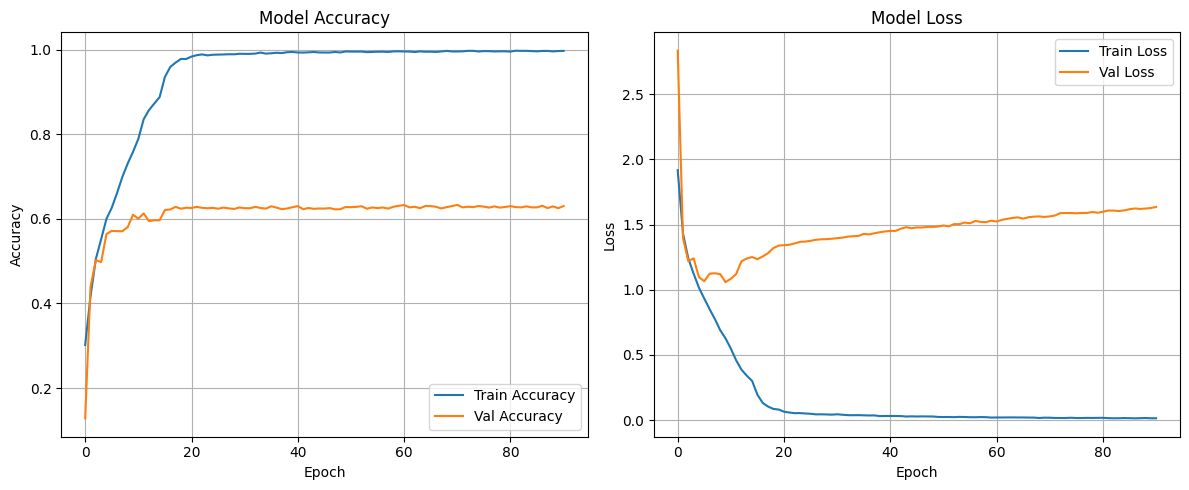

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from fer_cnn_utils import preprocess_frame, build_light_cnn
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam


def build_light_cnn(input_shape=(48, 48, 1), num_classes=7):
    """
    Lightweight CNN for emotion recognition from frames.
    """
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(256, (3,3), activation='relu', padding='same',),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        #Dropout(0.7),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    
    

    optimizer = Adam(learning_rate=3e-4) #### added (not in the paper)
    model.compile(optimizer=optimizer, #'adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving 
    #### added (not in the paper)
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(fer['label'].values)

cols = ['pixels', 'label']
fer_train, fer_val, fer_test = split_dataset_train_val_test(pd.concat([ck[cols], raf[cols], affect[cols]]))

# Apply preprocessing to all rows
X_train = np.stack(fer_train["pixels"].values)
X_val   = np.stack(fer_val["pixels"].values)
X_test  = np.stack(fer_test["pixels"].values)

y_train = label_encoder.transform(fer_train['label'].values)
y_val = label_encoder.transform(fer_val['label'].values)
y_test = label_encoder.transform(fer_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

162/162 [==============================] - 6s 32ms/step
              precision    recall  f1-score   support

       angry       0.51      0.52      0.51       578
     disgust       0.41      0.34      0.37       440
        fear       0.47      0.45      0.46       529
       happy       0.84      0.87      0.85      1187
     neutral       0.75      0.82      0.78      1092
         sad       0.45      0.43      0.44       627
    surprise       0.52      0.49      0.51       700

    accuracy                           0.63      5153
   macro avg       0.56      0.56      0.56      5153
weighted avg       0.62      0.63      0.62      5153



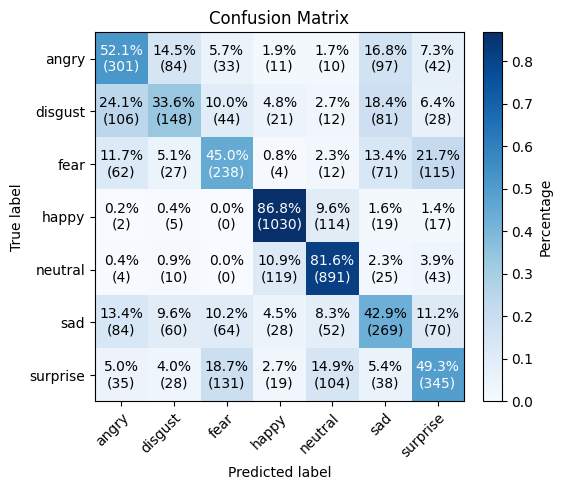

In [5]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

1122/1122 [==============================] - 35s 32ms/step
              precision    recall  f1-score   support

       angry       0.33      0.27      0.30      4953
     disgust       0.04      0.33      0.07       547
        fear       0.22      0.19      0.20      5121
       happy       0.68      0.29      0.41      8989
     neutral       0.30      0.15      0.20      6198
         sad       0.27      0.30      0.29      6077
    surprise       0.25      0.57      0.35      4002

    accuracy                           0.28     35887
   macro avg       0.30      0.30      0.26     35887
weighted avg       0.37      0.28      0.30     35887



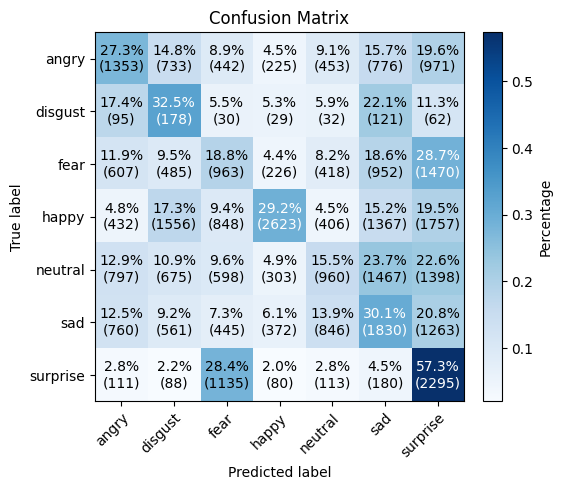

In [6]:
X_test = np.stack(fer["pixels"].values)
y_test = label_encoder.transform(fer['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

## Test on ck

Epoch 1/100
815/815 [==============================] - ETA: 0s - loss: 1.8114 - accuracy: 0.3049
Epoch 1: val_accuracy improved from -inf to 0.39260, saving model to best_cnn_model.h5
815/815 [==============================] - 99s 119ms/step - loss: 1.8114 - accuracy: 0.3049 - val_loss: 1.5697 - val_accuracy: 0.3926 - lr: 3.0000e-04
Epoch 2/100
  1/815 [..............................] - ETA: 1:28 - loss: 1.8648 - accuracy: 0.2812

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


815/815 [==============================] - ETA: 0s - loss: 1.4891 - accuracy: 0.4282
Epoch 2: val_accuracy improved from 0.39260 to 0.47043, saving model to best_cnn_model.h5
815/815 [==============================] - 94s 116ms/step - loss: 1.4891 - accuracy: 0.4282 - val_loss: 1.3942 - val_accuracy: 0.4704 - lr: 3.0000e-04
Epoch 3/100
815/815 [==============================] - ETA: 0s - loss: 1.3414 - accuracy: 0.4876
Epoch 3: val_accuracy improved from 0.47043 to 0.49046, saving model to best_cnn_model.h5
815/815 [==============================] - 95s 117ms/step - loss: 1.3414 - accuracy: 0.4876 - val_loss: 1.3505 - val_accuracy: 0.4905 - lr: 3.0000e-04
Epoch 4/100
815/815 [==============================] - ETA: 0s - loss: 1.2415 - accuracy: 0.5277
Epoch 4: val_accuracy improved from 0.49046 to 0.51941, saving model to best_cnn_model.h5
815/815 [==============================] - 95s 116ms/step - loss: 1.2415 - accuracy: 0.5277 - val_loss: 1.2738 - val_accuracy: 0.5194 - lr: 3.0000e-0

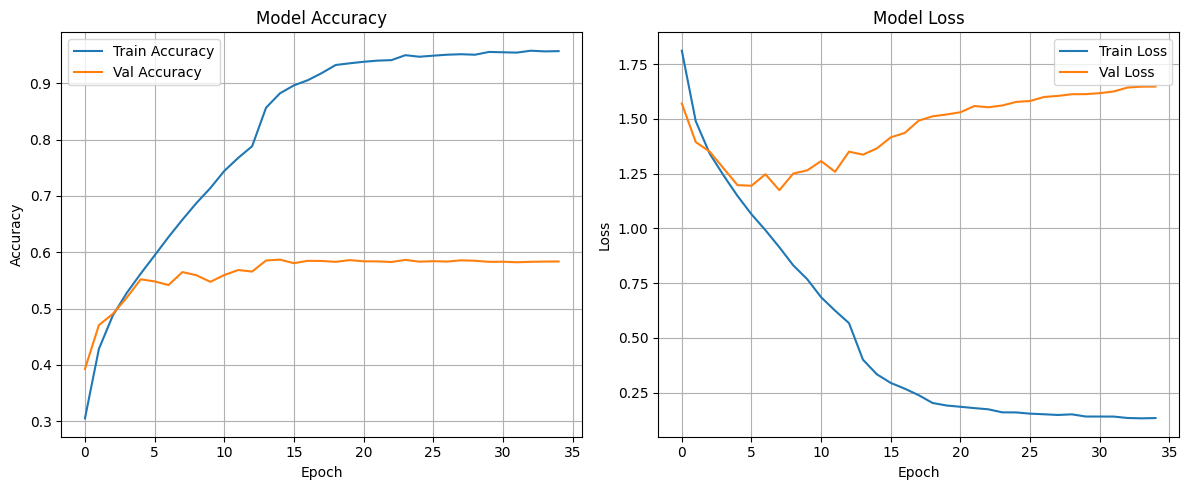

In [7]:
# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving 
    #### added (not in the paper)
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(fer['label'].values)

cols = ['pixels', 'label']
fer_train, fer_val, fer_test = split_dataset_train_val_test(pd.concat([fer[cols], raf[cols], affect[cols]]))

# Apply preprocessing to all rows
X_train = np.stack(fer_train["pixels"].values)
X_val   = np.stack(fer_val["pixels"].values)
X_test  = np.stack(fer_test["pixels"].values)

y_train = label_encoder.transform(fer_train['label'].values)
y_val = label_encoder.transform(fer_val['label'].values)
y_test = label_encoder.transform(fer_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

490/490 [==============================] - 15s 29ms/step
              precision    recall  f1-score   support

       angry       0.49      0.50      0.49      2050
     disgust       0.46      0.28      0.35       586
        fear       0.42      0.39      0.40      2058
       happy       0.80      0.79      0.80      3864
     neutral       0.59      0.60      0.60      2774
         sad       0.43      0.52      0.47      2442
    surprise       0.67      0.59      0.63      1875

    accuracy                           0.58     15649
   macro avg       0.55      0.53      0.53     15649
weighted avg       0.59      0.58      0.58     15649



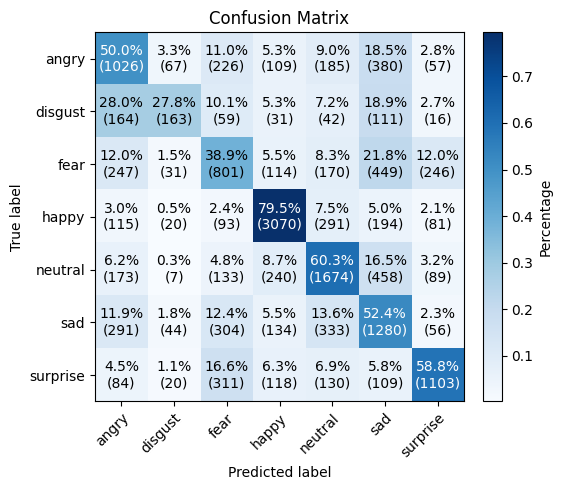

In [8]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

29/29 [==============================] - 1s 29ms/step
              precision    recall  f1-score   support

       angry       0.13      0.29      0.18        45
     disgust       0.86      0.10      0.18        59
        fear       0.15      0.20      0.17        25
       happy       0.88      1.00      0.94        69
     neutral       0.93      0.82      0.87       593
         sad       0.15      0.43      0.22        28
    surprise       0.93      0.92      0.92        83

    accuracy                           0.74       902
   macro avg       0.58      0.54      0.50       902
weighted avg       0.84      0.74      0.76       902



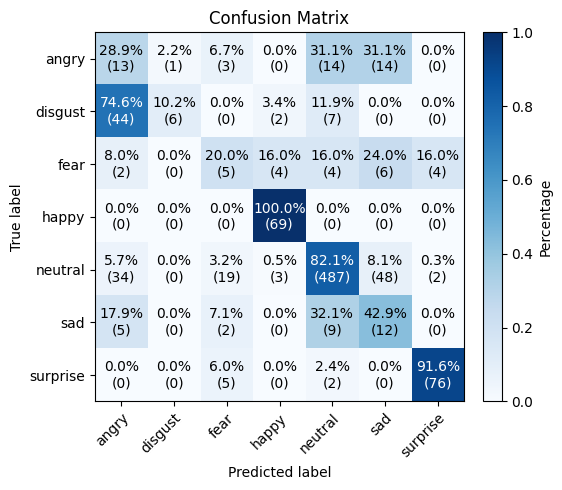

In [9]:
X_test = np.stack(ck["pixels"].values)
y_test = label_encoder.transform(ck['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

raf

In [ ]:
# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving 
    #### added (not in the paper)
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(fer['label'].values)

cols = ['pixels', 'label']
fer_train, fer_val, fer_test = split_dataset_train_val_test(pd.concat([fer[cols], affect[cols]]))

# Apply preprocessing to all rows
X_train = np.stack(fer_train["pixels"].values)
X_val   = np.stack(fer_val["pixels"].values)
X_test  = np.stack(fer_test["pixels"].values)

y_train = label_encoder.transform(fer_train['label'].values)
y_val = label_encoder.transform(fer_val['label'].values)
y_test = label_encoder.transform(fer_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

In [ ]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

X_test = np.stack(ck["pixels"].values)
y_test = label_encoder.transform(ck['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

In [ ]:
X_test = np.stack(raf["pixels"].values)
y_test = label_encoder.transform(raf['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

# FER2013

In [ ]:
import pandas as pd
# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving 
    #### added (not in the paper)
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(fer['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(fer_train["pixels"].values)
X_val   = np.stack(fer_val["pixels"].values)
X_test  = np.stack(fer_test["pixels"].values)

y_train = label_encoder.transform(fer_train['label'].values)
y_val = label_encoder.transform(fer_val['label'].values)
y_test = label_encoder.transform(fer_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

NameError: name 'ModelCheckpoint' is not defined

337/337 [==============================] - 11s 29ms/step
              precision    recall  f1-score   support

       angry       0.45      0.51      0.48      1486
     disgust       0.64      0.25      0.36       164
        fear       0.41      0.25      0.31      1536
       happy       0.77      0.80      0.78      2697
     neutral       0.46      0.60      0.52      1860
         sad       0.47      0.39      0.43      1823
    surprise       0.68      0.72      0.70      1201

    accuracy                           0.56     10767
   macro avg       0.55      0.50      0.51     10767
weighted avg       0.56      0.56      0.55     10767



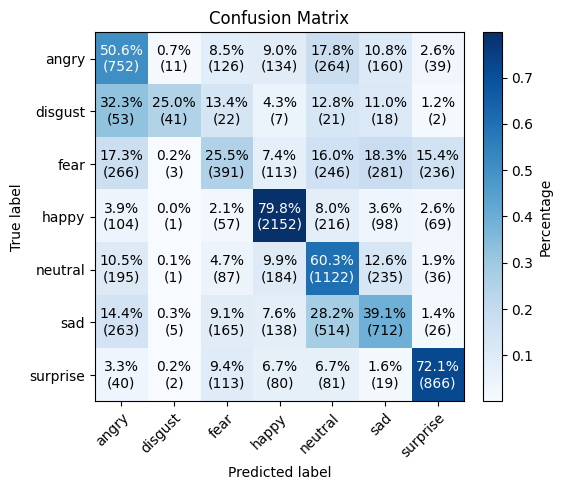

In [5]:

cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

29/29 [==============================] - 1s 31ms/step
              precision    recall  f1-score   support

       angry       0.18      0.29      0.22        45
     disgust       0.00      0.00      0.00        59
        fear       0.00      0.00      0.00        25
       happy       0.80      1.00      0.89        69
     neutral       0.89      0.97      0.93       593
         sad       0.43      0.11      0.17        28
    surprise       0.93      0.92      0.92        83

    accuracy                           0.82       902
   macro avg       0.46      0.47      0.45       902
weighted avg       0.75      0.82      0.78       902



/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

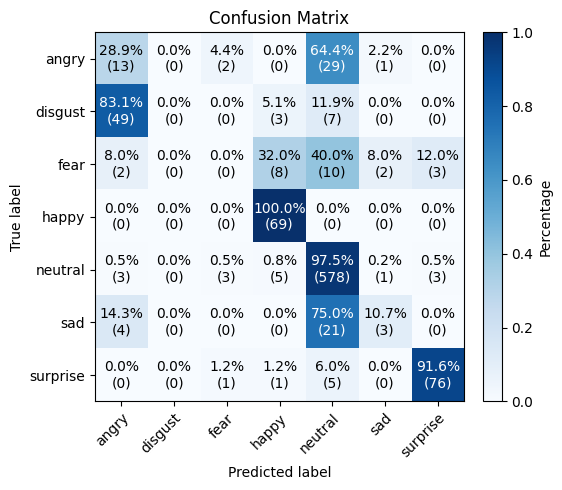

In [6]:
X_test = np.stack(ck["pixels"].values)
y_test = label_encoder.transform(ck['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

96/96 [==============================] - 3s 30ms/step
              precision    recall  f1-score   support

       angry       0.24      0.55      0.33       162
     disgust       0.33      0.04      0.07       160
        fear       0.16      0.14      0.15        74
       happy       0.75      0.81      0.78      1185
     neutral       0.51      0.55      0.53       680
         sad       0.38      0.44      0.41       478
    surprise       0.94      0.14      0.24       329

    accuracy                           0.55      3068
   macro avg       0.47      0.38      0.36      3068
weighted avg       0.60      0.55      0.53      3068



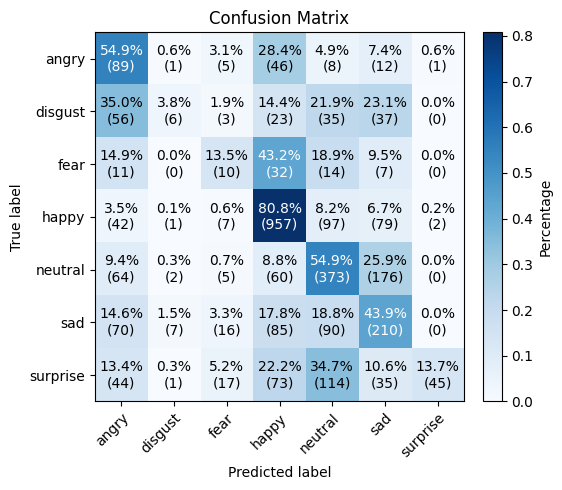

In [7]:
X_test = np.stack(raf["pixels"].values)
y_test = label_encoder.transform(raf['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

413/413 [==============================] - 13s 32ms/step
              precision    recall  f1-score   support

       angry       0.31      0.44      0.36      1718
     disgust       0.50      0.00      0.00      1248
        fear       0.32      0.12      0.17      1664
       happy       0.56      0.75      0.64      2704
     neutral       0.26      0.50      0.34      2368
         sad       0.19      0.14      0.16      1584
    surprise       0.44      0.16      0.23      1920

    accuracy                           0.36     13206
   macro avg       0.37      0.30      0.27     13206
weighted avg       0.38      0.36      0.31     13206



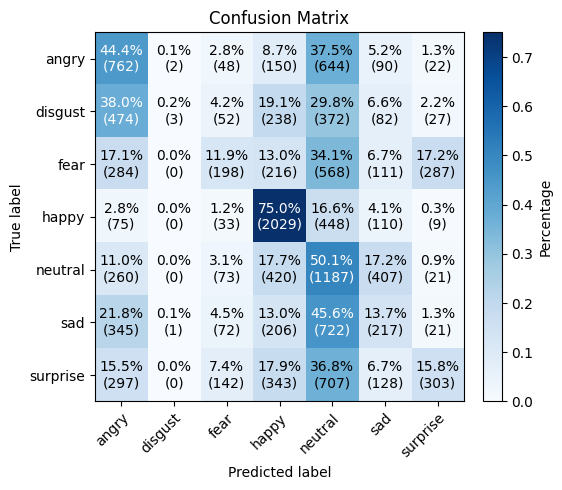

In [8]:
X_test = np.stack(affect["pixels"].values)
y_test = label_encoder.transform(affect['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### CK

Epoch 1/100
28/29 [===========================>..] - ETA: 0s - loss: 1.9222 - accuracy: 0.5826
Epoch 1: val_loss improved from inf to 1.93961, saving model to best_cnn_model.h5
29/29 [==============================] - 4s 81ms/step - loss: 1.9145 - accuracy: 0.5844 - val_loss: 1.9396 - val_accuracy: 0.0331 - lr: 3.0000e-04
Epoch 2/100
 2/29 [=>............................] - ETA: 1s - loss: 0.9231 - accuracy: 0.7812

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


28/29 [===========================>..] - ETA: 0s - loss: 0.7795 - accuracy: 0.7545
Epoch 2: val_loss improved from 1.93961 to 1.85221, saving model to best_cnn_model.h5
29/29 [==============================] - 2s 71ms/step - loss: 0.7793 - accuracy: 0.7533 - val_loss: 1.8522 - val_accuracy: 0.1989 - lr: 3.0000e-04
Epoch 3/100
28/29 [===========================>..] - ETA: 0s - loss: 0.5310 - accuracy: 0.8080
Epoch 3: val_loss improved from 1.85221 to 1.64549, saving model to best_cnn_model.h5
29/29 [==============================] - 2s 74ms/step - loss: 0.5335 - accuracy: 0.8067 - val_loss: 1.6455 - val_accuracy: 0.6575 - lr: 3.0000e-04
Epoch 4/100
28/29 [===========================>..] - ETA: 0s - loss: 0.4764 - accuracy: 0.8304
Epoch 4: val_loss improved from 1.64549 to 1.59275, saving model to best_cnn_model.h5
29/29 [==============================] - 2s 70ms/step - loss: 0.4747 - accuracy: 0.8311 - val_loss: 1.5928 - val_accuracy: 0.6575 - lr: 3.0000e-04
Epoch 5/100
28/29 [=========

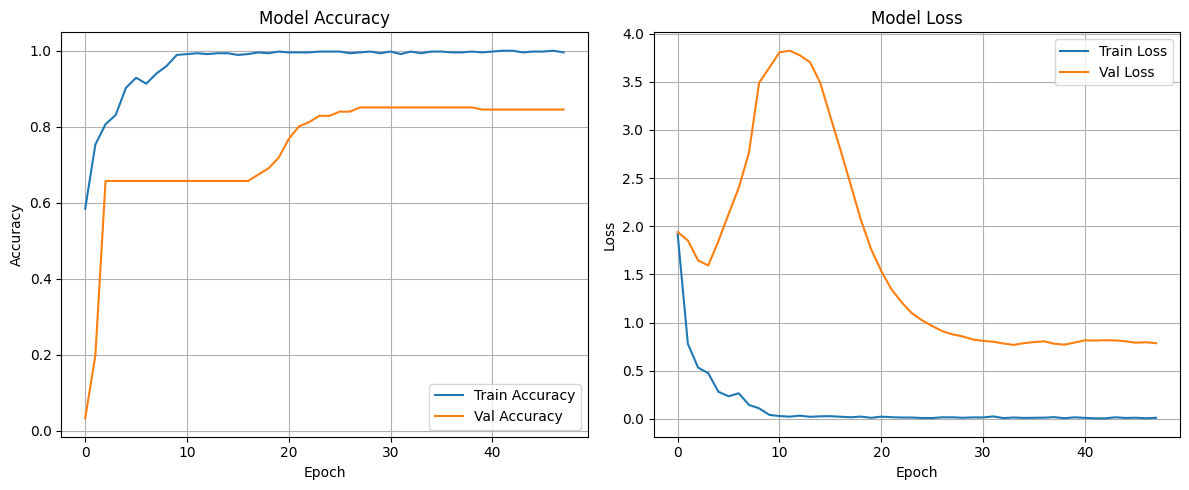

In [ ]:
# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving 
    #### added (not in the paper)
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(ck['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(ck_train["pixels"].values)
X_val   = np.stack(ck_val["pixels"].values)
X_test  = np.stack(ck_test["pixels"].values)

y_train = label_encoder.transform(ck_train['label'].values)
y_val = label_encoder.transform(ck_val['label'].values)
y_test = label_encoder.transform(ck_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

9/9 [==============================] - 1s 35ms/step
              precision    recall  f1-score   support

       angry       1.00      0.14      0.25        14
     disgust       1.00      0.78      0.88        18
        fear       0.00      0.00      0.00         7
       happy       1.00      0.95      0.98        21
     neutral       0.85      1.00      0.92       178
         sad       0.50      0.12      0.20         8
    surprise       1.00      0.92      0.96        25

    accuracy                           0.88       271
   macro avg       0.76      0.56      0.60       271
weighted avg       0.86      0.88      0.84       271



/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

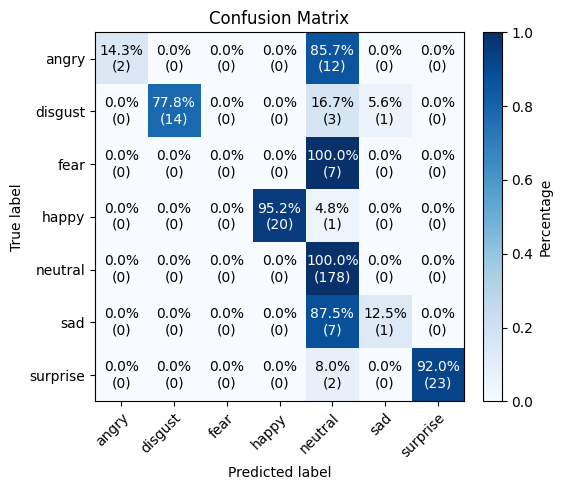

In [5]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

1122/1122 [==============================] - 36s 32ms/step
              precision    recall  f1-score   support

       angry       0.20      0.06      0.10      4953
     disgust       0.03      0.07      0.04       547
        fear       0.14      0.01      0.02      5121
       happy       0.37      0.11      0.16      8989
     neutral       0.20      0.79      0.31      6198
         sad       0.18      0.01      0.03      6077
    surprise       0.24      0.28      0.26      4002

    accuracy                           0.21     35887
   macro avg       0.19      0.19      0.13     35887
weighted avg       0.23      0.21      0.15     35887



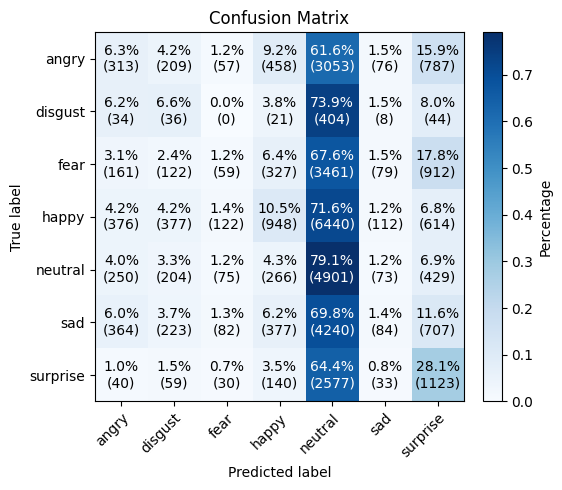

In [6]:
X_test = np.stack(fer["pixels"].values)
y_test = label_encoder.transform(fer['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

96/96 [==============================] - 3s 31ms/step
              precision    recall  f1-score   support

       angry       0.13      0.04      0.07       162
     disgust       0.07      0.04      0.05       160
        fear       0.19      0.04      0.07        74
       happy       0.31      0.04      0.07      1185
     neutral       0.24      0.91      0.38       680
         sad       0.12      0.00      0.00       478
    surprise       0.15      0.05      0.08       329

    accuracy                           0.23      3068
   macro avg       0.17      0.16      0.10      3068
weighted avg       0.22      0.23      0.13      3068



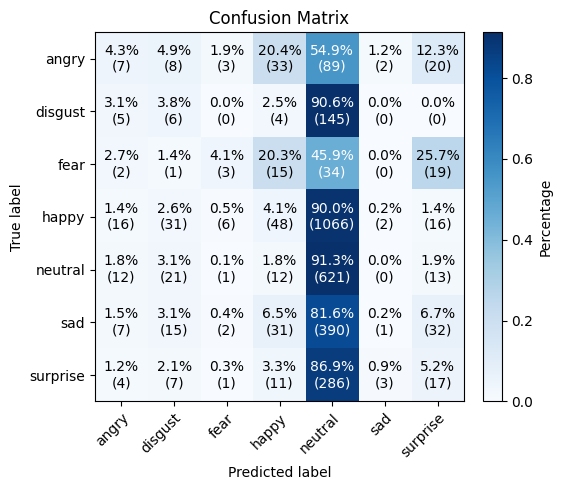

In [7]:
X_test = np.stack(raf["pixels"].values)
y_test = label_encoder.transform(raf['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

413/413 [==============================] - 13s 33ms/step
              precision    recall  f1-score   support

       angry       0.17      0.09      0.12      1718
     disgust       0.14      0.12      0.13      1248
        fear       0.14      0.02      0.03      1664
       happy       0.31      0.17      0.22      2704
     neutral       0.18      0.51      0.27      2368
         sad       0.14      0.02      0.04      1584
    surprise       0.18      0.23      0.20      1920

    accuracy                           0.19     13206
   macro avg       0.18      0.17      0.14     13206
weighted avg       0.19      0.19      0.16     13206



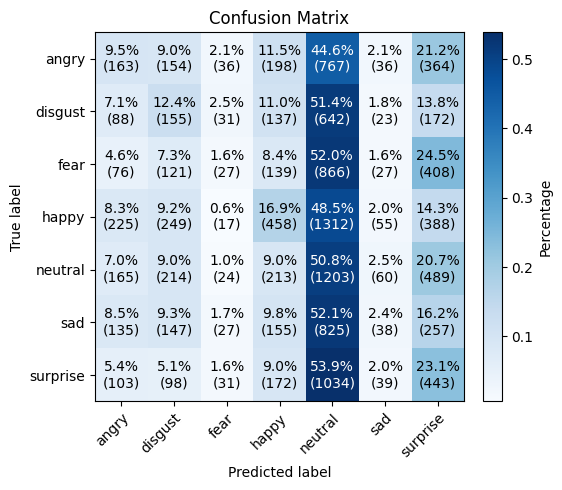

In [8]:
X_test = np.stack(affect["pixels"].values)
y_test = label_encoder.transform(affect['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### RAF-DB

Epoch 1/100
96/96 [==============================] - ETA: 0s - loss: 2.1802 - accuracy: 0.3509
Epoch 1: val_loss improved from inf to 1.78124, saving model to best_cnn_model.h5
96/96 [==============================] - 9s 74ms/step - loss: 2.1802 - accuracy: 0.3509 - val_loss: 1.7812 - val_accuracy: 0.3860 - lr: 3.0000e-04
Epoch 2/100
 1/96 [..............................] - ETA: 6s - loss: 1.6432 - accuracy: 0.4375

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


96/96 [==============================] - ETA: 0s - loss: 1.4710 - accuracy: 0.4677
Epoch 2: val_loss did not improve from 1.78124
96/96 [==============================] - 7s 68ms/step - loss: 1.4710 - accuracy: 0.4677 - val_loss: 2.2334 - val_accuracy: 0.2215 - lr: 3.0000e-04
Epoch 3/100
96/96 [==============================] - ETA: 0s - loss: 1.3290 - accuracy: 0.5290
Epoch 3: val_loss did not improve from 1.78124
96/96 [==============================] - 7s 68ms/step - loss: 1.3290 - accuracy: 0.5290 - val_loss: 1.9634 - val_accuracy: 0.3176 - lr: 3.0000e-04
Epoch 4/100
95/96 [============================>.] - ETA: 0s - loss: 1.1524 - accuracy: 0.5921
Epoch 4: val_loss did not improve from 1.78124
96/96 [==============================] - 7s 69ms/step - loss: 1.1503 - accuracy: 0.5936 - val_loss: 1.8475 - val_accuracy: 0.2980 - lr: 3.0000e-04
Epoch 5/100
96/96 [==============================] - ETA: 0s - loss: 1.0210 - accuracy: 0.6295
Epoch 5: val_loss improved from 1.78124 to 1.71862

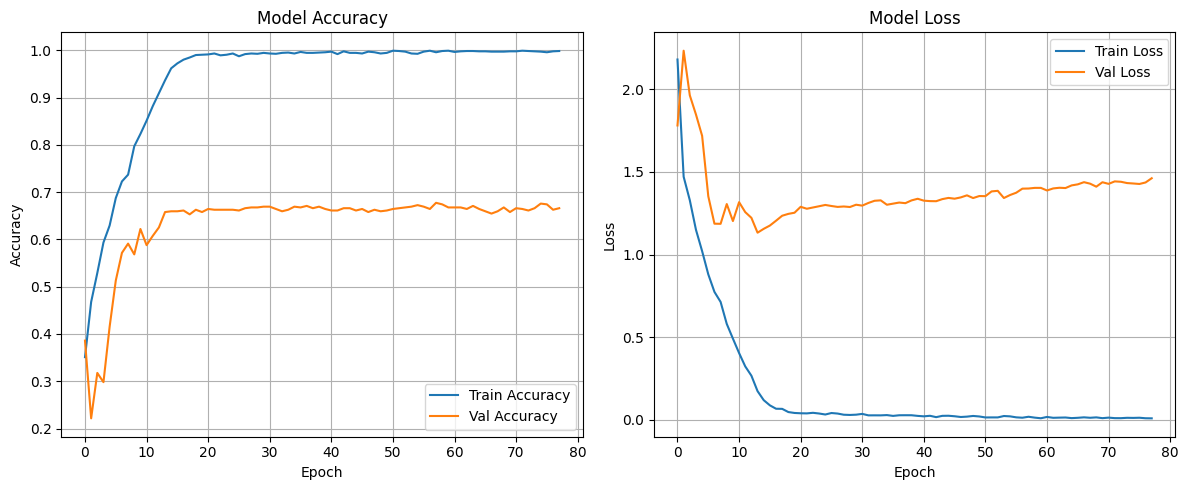

In [ ]:
# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving 
    #### added (not in the paper)
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(raf['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(raf_train["pixels"].values)
X_val   = np.stack(raf_val["pixels"].values)
X_test  = np.stack(raf_test["pixels"].values)

y_train = label_encoder.transform(raf_train['label'].values)
y_val = label_encoder.transform(raf_val['label'].values)
y_test = label_encoder.transform(raf_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

29/29 [==============================] - 1s 31ms/step
              precision    recall  f1-score   support

       angry       0.50      0.35      0.41        49
     disgust       0.23      0.15      0.18        48
        fear       0.75      0.27      0.40        22
       happy       0.75      0.89      0.81       356
     neutral       0.55      0.62      0.58       204
         sad       0.51      0.43      0.46       143
    surprise       0.71      0.55      0.62        99

    accuracy                           0.64       921
   macro avg       0.57      0.46      0.49       921
weighted avg       0.62      0.64      0.62       921



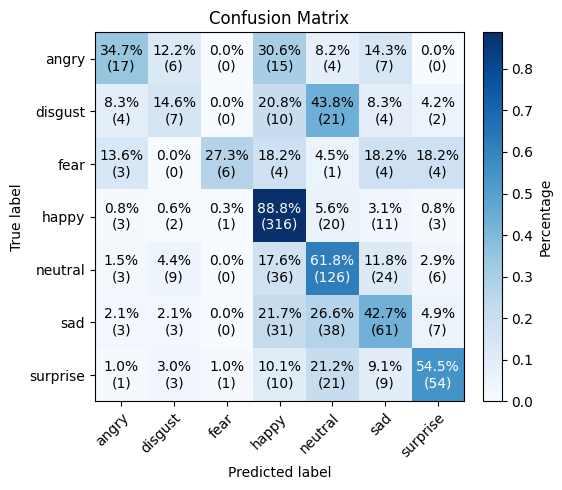

In [5]:
cnn = load_model("best_cnn_model.h5")
y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

1122/1122 [==============================] - 35s 31ms/step
              precision    recall  f1-score   support

       angry       0.26      0.10      0.14      4953
     disgust       0.02      0.09      0.04       547
        fear       0.20      0.02      0.04      5121
       happy       0.45      0.62      0.52      8989
     neutral       0.32      0.29      0.30      6198
         sad       0.26      0.28      0.27      6077
    surprise       0.31      0.53      0.40      4002

    accuracy                           0.33     35887
   macro avg       0.26      0.28      0.24     35887
weighted avg       0.31      0.33      0.30     35887



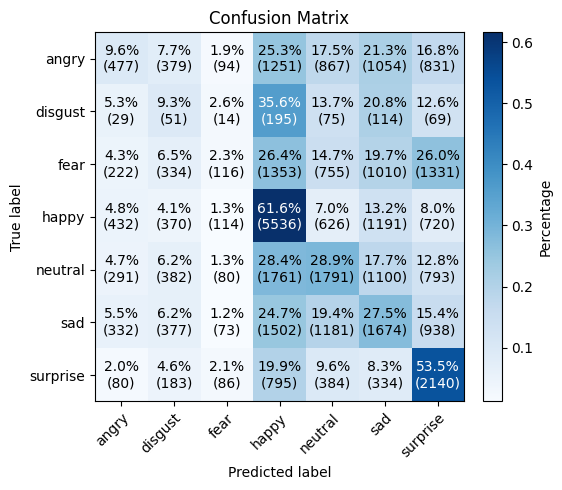

In [6]:
X_test = np.stack(fer["pixels"].values)
y_test = label_encoder.transform(fer['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

29/29 [==============================] - 1s 33ms/step
              precision    recall  f1-score   support

       angry       0.11      0.09      0.10        45
     disgust       0.10      0.07      0.08        59
        fear       0.00      0.00      0.00        25
       happy       0.20      0.99      0.33        69
     neutral       0.84      0.42      0.56       593
         sad       0.06      0.07      0.06        28
    surprise       0.54      0.88      0.67        83

    accuracy                           0.44       902
   macro avg       0.26      0.36      0.26       902
weighted avg       0.63      0.44      0.47       902



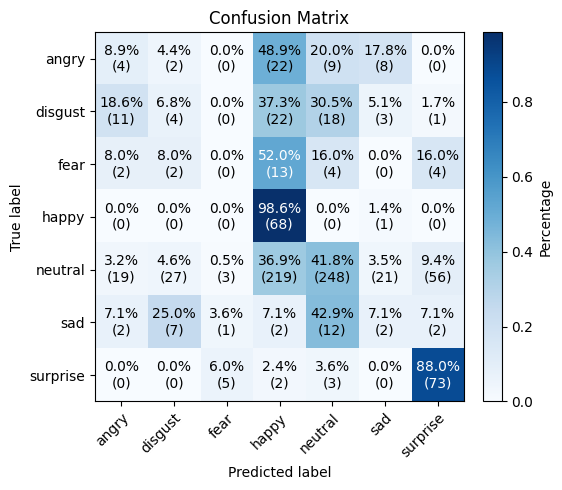

In [7]:
X_test = np.stack(ck["pixels"].values)
y_test = label_encoder.transform(ck['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

413/413 [==============================] - 13s 32ms/step
              precision    recall  f1-score   support

       angry       0.19      0.13      0.15      1718
     disgust       0.10      0.06      0.08      1248
        fear       0.18      0.03      0.05      1664
       happy       0.22      0.24      0.23      2704
     neutral       0.19      0.18      0.19      2368
         sad       0.12      0.28      0.17      1584
    surprise       0.22      0.25      0.23      1920

    accuracy                           0.18     13206
   macro avg       0.17      0.17      0.16     13206
weighted avg       0.18      0.18      0.17     13206



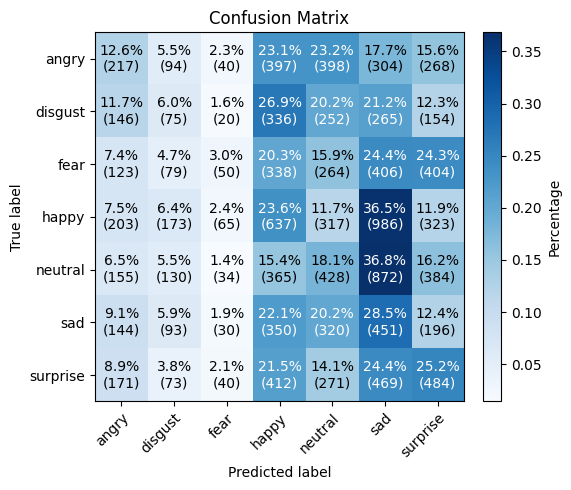

In [8]:
X_test = np.stack(affect["pixels"].values)
y_test = label_encoder.transform(affect['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

### AffectNet

Epoch 1/100
206/207 [============================>.] - ETA: 0s - loss: 1.8708 - accuracy: 0.2914
Epoch 1: val_accuracy improved from inf to 0.09576, saving model to best_cnn_model.h5
207/207 [==============================] - 30s 134ms/step - loss: 1.8704 - accuracy: 0.2914 - val_loss: 2.4702 - val_accuracy: 0.0958 - lr: 3.0000e-04
Epoch 2/100
  1/207 [..............................] - ETA: 22s - loss: 1.3038 - accuracy: 0.3750

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


206/207 [============================>.] - ETA: 0s - loss: 1.3858 - accuracy: 0.4058
Epoch 2: val_accuracy did not improve from 0.09576
207/207 [==============================] - 25s 121ms/step - loss: 1.3861 - accuracy: 0.4058 - val_loss: 1.5510 - val_accuracy: 0.3497 - lr: 3.0000e-04
Epoch 3/100
206/207 [============================>.] - ETA: 0s - loss: 1.2474 - accuracy: 0.4738
Epoch 3: val_accuracy did not improve from 0.09576
207/207 [==============================] - 26s 125ms/step - loss: 1.2470 - accuracy: 0.4739 - val_loss: 1.2406 - val_accuracy: 0.4765 - lr: 3.0000e-04
Epoch 4/100
206/207 [============================>.] - ETA: 0s - loss: 1.1462 - accuracy: 0.5124
Epoch 4: val_accuracy did not improve from 0.09576
207/207 [==============================] - 28s 138ms/step - loss: 1.1461 - accuracy: 0.5123 - val_loss: 1.1671 - val_accuracy: 0.5049 - lr: 3.0000e-04
Epoch 5/100
206/207 [============================>.] - ETA: 0s - loss: 1.0480 - accuracy: 0.5625
Epoch 5: val_accur

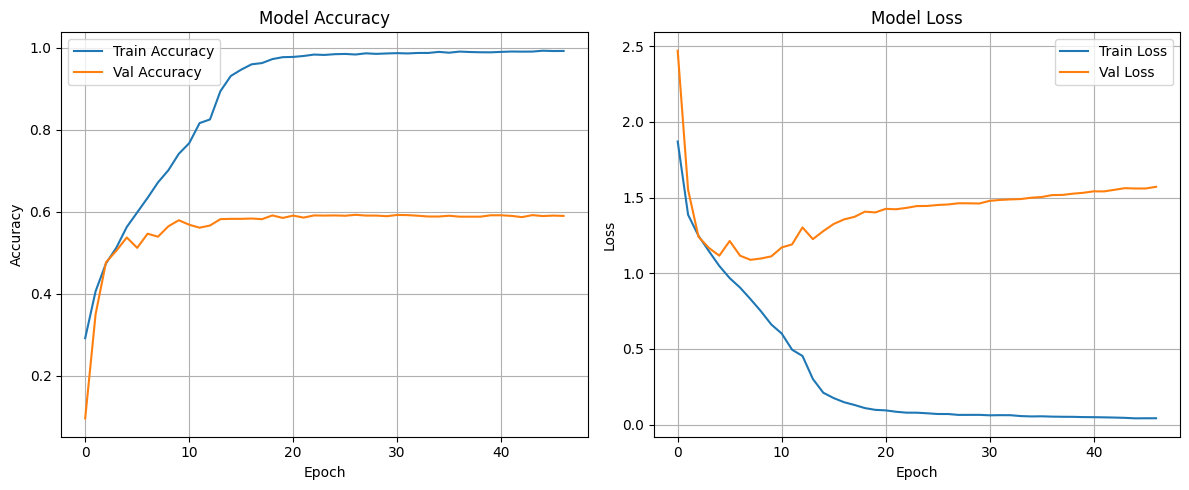

In [9]:
# Callbacks for better training control
callbacks = [
    # Save only the best model (based on validation accuracy)
    ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        #monitor="val_loss",
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when validation stops improving 
    #### added (not in the paper)
    ReduceLROnPlateau(
        monitor="val_loss",
        #monitor="val_accuracy",
        factor=0.25,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

# Encode string labels -> integers
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(affect['label'].values)


# Apply preprocessing to all rows
X_train = np.stack(affect_train["pixels"].values)
X_val   = np.stack(affect_val["pixels"].values)
X_test  = np.stack(affect_test["pixels"].values)

y_train = label_encoder.transform(affect_train['label'].values)
y_val = label_encoder.transform(affect_val['label'].values)
y_test = label_encoder.transform(affect_test['label'].values)


cnn = build_light_cnn()
history = cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=callbacks,
)

plot_training_history(history)

83/83 [==============================] - 3s 34ms/step
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       343
     disgust       0.09      0.95      0.17       250
        fear       0.00      0.00      0.00       333
       happy       0.00      0.00      0.00       541
     neutral       0.00      0.00      0.00       474
         sad       0.18      0.05      0.08       317
    surprise       0.00      0.00      0.00       384

    accuracy                           0.10      2642
   macro avg       0.04      0.14      0.04      2642
weighted avg       0.03      0.10      0.03      2642



/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

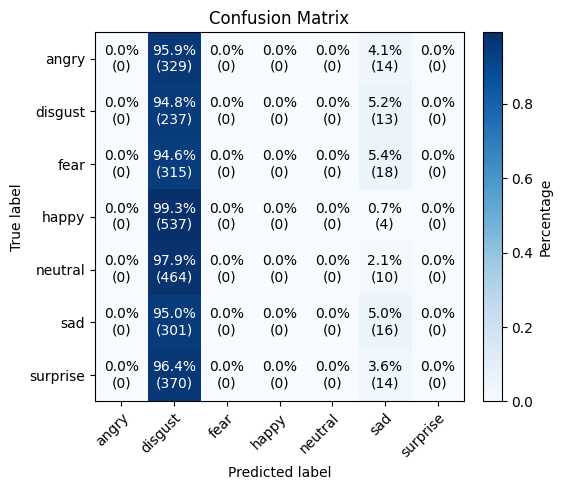

In [10]:
cnn = load_model("best_cnn_model.h5")

y_pred_probs = cnn.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_val = label_encoder.inverse_transform(y_val)

print(classification_report(y_val, y_pred))
plot_confusion_matrix(y_val, y_pred)

In [16]:
cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 48, 48, 32)        320       
                                                                 
 batch_normalization_4 (Bat  (None, 48, 48, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 24, 24, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 batch_normalization_5 (Bat  (None, 24, 24, 64)        256       
 chNormalization)                                                
                                                      

124/124 [==============================] - 4s 36ms/step
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       516
     disgust       0.09      0.96      0.17       374
        fear       0.00      0.00      0.00       499
       happy       0.00      0.00      0.00       811
     neutral       0.00      0.00      0.00       711
         sad       0.19      0.05      0.08       475
    surprise       0.00      0.00      0.00       576

    accuracy                           0.10      3962
   macro avg       0.04      0.14      0.04      3962
weighted avg       0.03      0.10      0.03      3962



/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

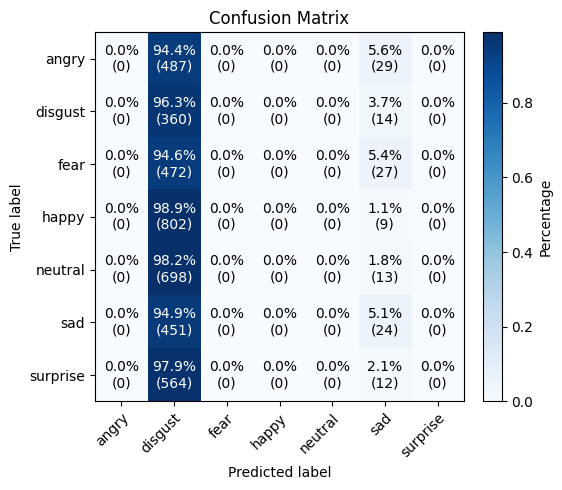

In [11]:

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

1122/1122 [==============================] - 37s 33ms/step


/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

              precision    recall  f1-score   support

       angry       0.00      0.00      0.00      4953
     disgust       0.02      0.99      0.03       547
        fear       0.00      0.00      0.00      5121
       happy       0.00      0.00      0.00      8989
     neutral       0.00      0.00      0.00      6198
         sad       0.23      0.03      0.05      6077
    surprise       0.00      0.00      0.00      4002

    accuracy                           0.02     35887
   macro avg       0.03      0.14      0.01     35887
weighted avg       0.04      0.02      0.01     35887



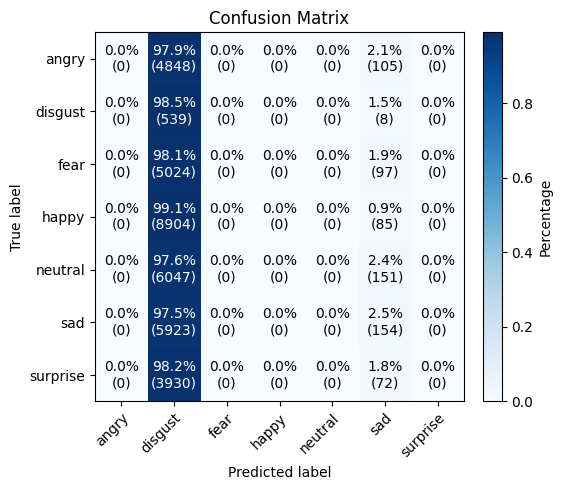

In [12]:
X_test = np.stack(fer["pixels"].values)
y_test = label_encoder.transform(fer['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

29/29 [==============================] - 1s 31ms/step
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        45
     disgust       0.07      0.98      0.13        59
        fear       0.00      0.00      0.00        25
       happy       0.00      0.00      0.00        69
     neutral       0.00      0.00      0.00       593
         sad       0.00      0.00      0.00        28
    surprise       0.00      0.00      0.00        83

    accuracy                           0.06       902
   macro avg       0.01      0.14      0.02       902
weighted avg       0.00      0.06      0.01       902



/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

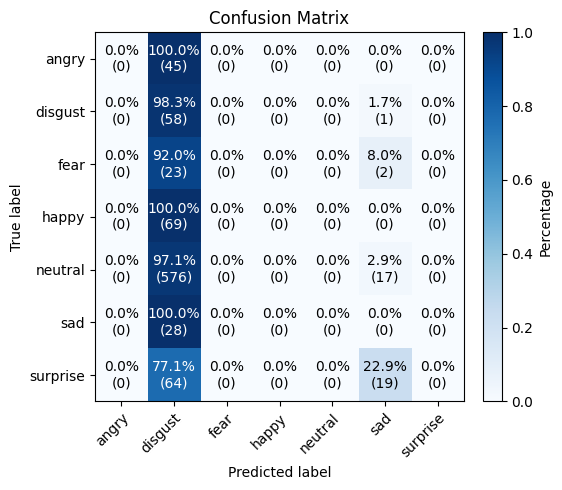

In [13]:
X_test = np.stack(ck["pixels"].values)
y_test = label_encoder.transform(ck['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

96/96 [==============================] - 3s 32ms/step
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       162
     disgust       0.05      1.00      0.10       160
        fear       0.00      0.00      0.00        74
       happy       0.00      0.00      0.00      1185
     neutral       0.00      0.00      0.00       680
         sad       0.22      0.00      0.01       478
    surprise       0.00      0.00      0.00       329

    accuracy                           0.05      3068
   macro avg       0.04      0.14      0.02      3068
weighted avg       0.04      0.05      0.01      3068



/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

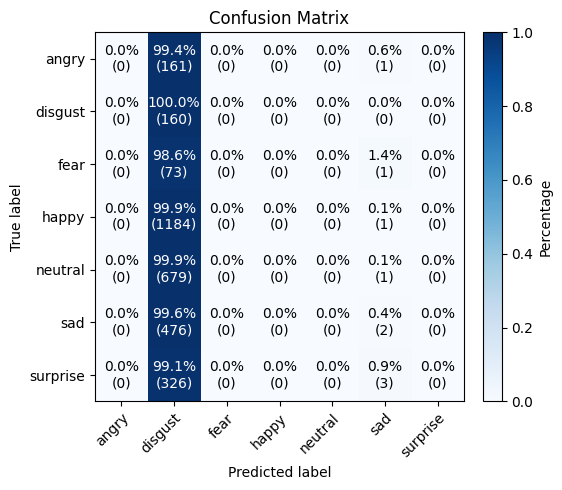

In [14]:
X_test = np.stack(raf["pixels"].values)
y_test = label_encoder.transform(raf['label'].values)

y_pred_probs = cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred = label_encoder.inverse_transform(y_pred)
y_test = label_encoder.inverse_transform(y_test)

print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)